Размер изображения: (400, 600)


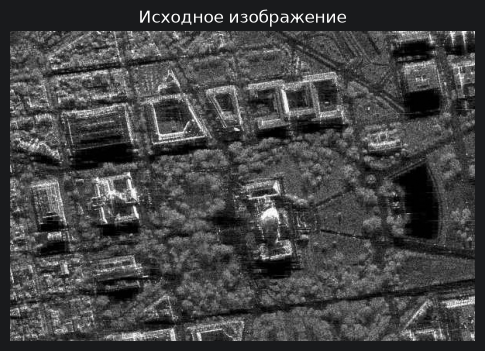

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import mean_squared_error

img = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

print("Размер изображения:", img.shape)
plt.figure(figsize=(6,5))
plt.imshow(img, cmap='gray')
plt.title("Исходное изображение")
plt.axis("off")
plt.show()


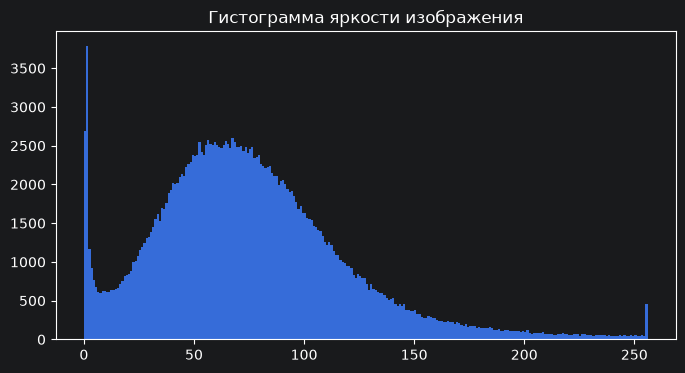

In [16]:
plt.figure(figsize=(8,4))
plt.hist(img.ravel(),bins=256,range=[0,256])
plt.title("Гистограмма яркости изображения")
plt.show()

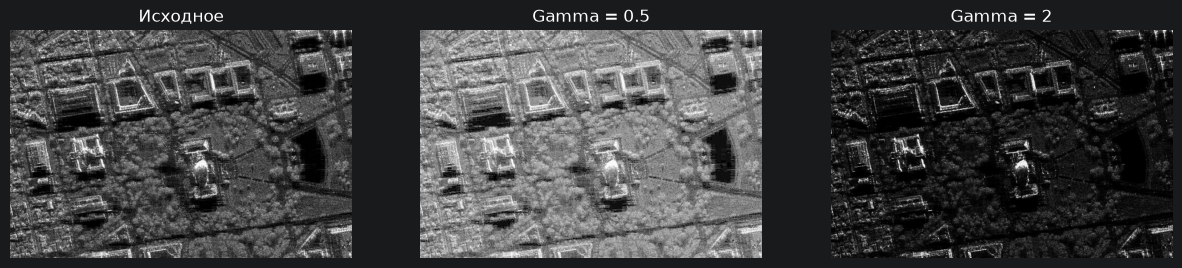

In [17]:
#Гамма-коррекция с параметром гамма <1, >1.
def gamma_transform(image, gamma):
    return np.uint8(np.power(image / 255.0, gamma) * 255)
gamma_low = gamma_transform(img,0.5)
gamma_high = gamma_transform(img,2.0)
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img,cmap='gray')
plt.title("Исходное")
plt.axis("off")

#<1
plt.subplot(1,3,2)
plt.imshow(gamma_low,cmap='gray')
plt.title("Gamma = 0.5")
plt.axis("off")

#>1
plt.subplot(1,3,3)
plt.imshow(gamma_high,cmap='gray')
plt.title("Gamma = 2")
plt.axis("off")

plt.show()

In [18]:
#Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
def calculate_metrics(original, processed):
    mse_value = mean_squared_error(original.flatten(),processed.flatten())
    ssim_value = ssim(original,processed,data_range=255)
    return mse_value, ssim_value
mse1, ssim1 = calculate_metrics(img,gamma_low)
mse2, ssim2 = calculate_metrics(img,gamma_high)

print("Gamma 0.5")
print("MSE:",mse1)
print("SSIM:",ssim1)

print("\nGamma 2")
print("MSE:",mse2)
print("SSIM:",ssim2)

Gamma 0.5
MSE: 3250.429145833333
SSIM: 0.7875008686792752

Gamma 2
MSE: 2383.7636375
SSIM: 0.5270459922820343


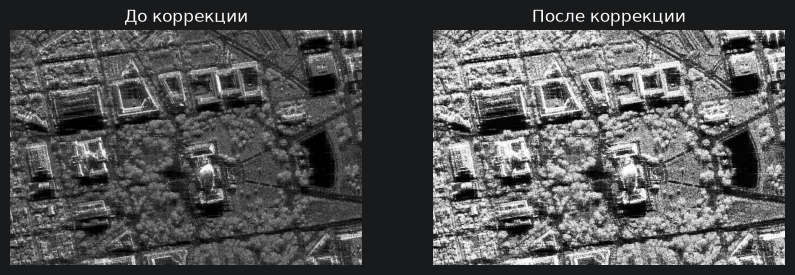

In [19]:
#Статистическая цветокоррекция
corrected = cv2.equalizeHist(img)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img,cmap='gray')
plt.title("До коррекции")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(corrected,cmap='gray')
plt.title("После коррекции")
plt.axis("off")
plt.show()

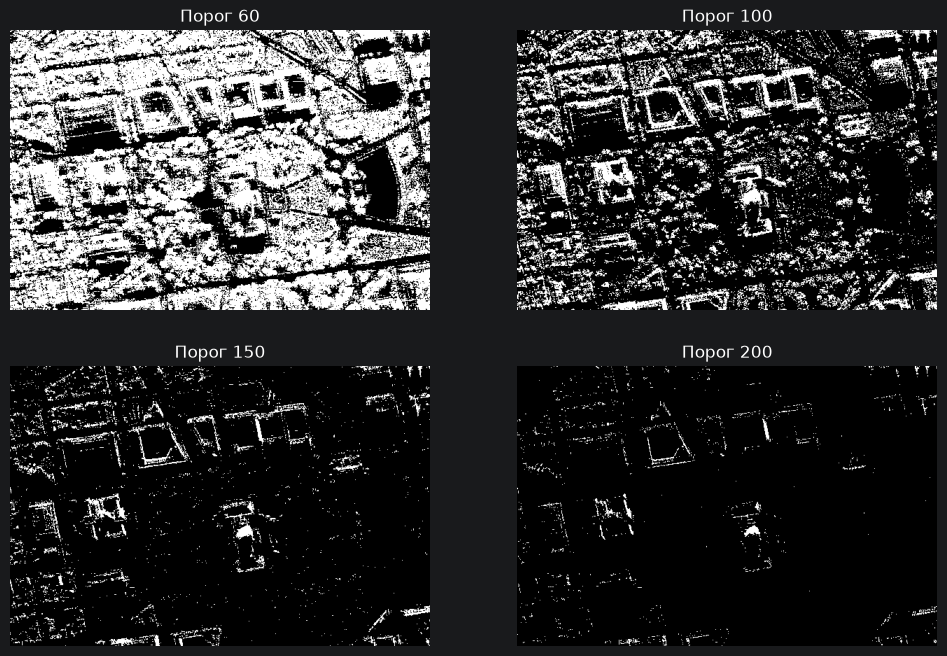

In [20]:
#Пороговая фильтрация
thresholds = [60,100,150,200]

plt.figure(figsize=(12,8))

for i,t in enumerate(thresholds):
    _,result=cv2.threshold(img,t,255,cv2.THRESH_BINARY)
    plt.subplot(2,2,i+1)
    plt.imshow(result,cmap='gray')
    plt.title(f"Порог {t}")
    plt.axis("off")

plt.show()